In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
data = pd.read_csv('categorical_data_assignment.csv')

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Customer_ID          50 non-null     object 
 1   Age                  45 non-null     float64
 2   Gender               50 non-null     object 
 3   City                 50 non-null     object 
 4   Annual_Income        50 non-null     float64
 5   Education_Level      50 non-null     object 
 6   Purchase_Frequency   50 non-null     float64
 7   Subscription_Status  50 non-null     object 
 8   Credit_Score         45 non-null     float64
 9   Product_Category     50 non-null     object 
dtypes: float64(4), object(6)
memory usage: 4.0+ KB


In [4]:
data.head()

,Customer_ID,Age,Gender,City,Annual_Income,Education_Level,Purchase_Frequency,Subscription_Status,Credit_Score,Product_Category
0,CUST_1,56.0,Other,Chicago,42053.596943,Master's,3.0,Active,NaN,Electronics
1,CUST_2,46.0,Other,New York,57699.011497,Master's,25.0,Inactive,NaN,Sports
2,CUST_3,32.0,Male,Chicago,51456.163240,Bachelor's,29.0,Active,667.889368,Sports
3,CUST_4,60.0,Other,Miami,64529.674858,Bachelor's,18.0,Inactive,678.039226,Electronics
4,CUST_5,25.0,Other,Los Angeles,39469.203592,Master's,14.0,Active,704.152562,Sports


In [5]:
data.columns

Index(['Customer_ID', 'Age', 'Gender', 'City', 'Annual_Income',
       'Education_Level', 'Purchase_Frequency', 'Subscription_Status',
       'Credit_Score', 'Product_Category'],
      dtype='object')

In [6]:
#Identify all categorical columns
# It can be done by two way 
[col for col in data.columns if data[col].dtype == "object"] #list comprehension

['Customer_ID',
 'Gender',
 'City',
 'Education_Level',
 'Subscription_Status',
 'Product_Category']

In [7]:
objectColumns = []
for col in data.columns:
  if data[col].dtype == "object":
    objectColumns.append(col)

In [8]:
#OHE Gender Solution

In [9]:
# Convert Product_Category using Freq Encoding

In [10]:
freq = data['Product_Category'].value_counts(normalize=True)
freq

Product_Category
Sports         0.28
Beauty         0.24
Clothing       0.22
Electronics    0.16
Home           0.10
Name: proportion, dtype: float64

In [11]:
#Target Encode `Subscription_Status` using `Purchase_Frequency` as target

In [12]:
groupedData = data.groupby('Subscription_Status')['Purchase_Frequency'].mean()
data['Encoded_Subscription_Status'] = data['Subscription_Status'].map(groupedData)

print(data[['Subscription_Status', 'Encoded_Subscription_Status']])

   Subscription_Status  Encoded_Subscription_Status
0               Active                        17.56
1             Inactive                        18.36
2               Active                        17.56
3             Inactive                        18.36
4               Active                        17.56
5             Inactive                        18.36
6               Active                        17.56
7             Inactive                        18.36
8               Active                        17.56
9             Inactive                        18.36
10            Inactive                        18.36
11            Inactive                        18.36
12              Active                        17.56
13            Inactive                        18.36
14              Active                        17.56
15            Inactive                        18.36
16              Active                        17.56
17            Inactive                        18.36
18          

In [13]:
#Identify missing values in the dataset
data.isna().sum()

# Age
# Credit_Score

Customer_ID                    0
Age                            5
Gender                         0
City                           0
Annual_Income                  0
Education_Level                0
Purchase_Frequency             0
Subscription_Status            0
Credit_Score                   5
Product_Category               0
Encoded_Subscription_Status    0
dtype: int64

In [14]:
# Fill missing values in Age using median

data['Age'].fillna(data['Age'].median(), inplace=True)

C:\Users\shrid\AppData\Local\Temp\ipykernel_35984\924888923.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].median(), inplace=True)


In [15]:
# Replace missing CreditScore with mean

data['Credit_Score'].fillna(data['Credit_Score'].mean() , inplace=True)

C:\Users\shrid\AppData\Local\Temp\ipykernel_35984\2027327373.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Credit_Score'].fillna(data['Credit_Score'].mean() , inplace=True)


In [16]:
# Ordinal encode Education_level

data['Education_Level'].unique()

array(["Master's", "Bachelor's", 'PhD', 'High School'], dtype=object)

In [17]:
mapping = {"High School": 0,
"Bachelor's": 1,
           "Master's": 2,
           "PhD": 3}

data['Ed_lvl1'] = data['Education_Level'].map(mapping)
data.head()

,Customer_ID,Age,Gender,City,Annual_Income,Education_Level,Purchase_Frequency,Subscription_Status,Credit_Score,Product_Category,Encoded_Subscription_Status,Ed_lvl1
0,CUST_1,56.0,Other,Chicago,42053.596943,Master's,3.0,Active,654.899579,Electronics,17.56,2
1,CUST_2,46.0,Other,New York,57699.011497,Master's,25.0,Inactive,654.899579,Sports,18.36,2
2,CUST_3,32.0,Male,Chicago,51456.163240,Bachelor's,29.0,Active,667.889368,Sports,17.56,1
3,CUST_4,60.0,Other,Miami,64529.674858,Bachelor's,18.0,Inactive,678.039226,Electronics,18.36,1
4,CUST_5,25.0,Other,Los Angeles,39469.203592,Master's,14.0,Active,704.152562,Sports,17.56,2


In [18]:
data.describe()

,Age,Annual_Income,Purchase_Frequency,Credit_Score,Encoded_Subscription_Status,Ed_lvl1
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,39.700000,52896.709285,17.960000,654.899579,17.960000,1.820000
std,12.377151,24322.517256,19.187538,52.066577,0.404061,1.172647
min,19.000000,21218.431771,1.000000,548.742871,17.560000,0.000000
25%,31.250000,39978.286208,6.000000,619.497943,17.560000,1.000000
50%,39.000000,49540.807661,16.000000,654.899579,17.960000,2.000000
75%,46.750000,56843.105558,22.000000,680.908095,18.360000,3.000000
max,64.000000,150000.000000,100.000000,842.636575,18.360000,3.000000


In [19]:
#Visual EDA

# 1. Distribution Plot ---- KDE plot
# 2. Box plot


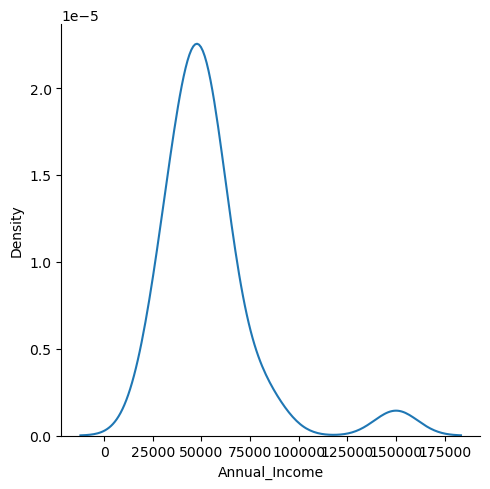

In [20]:
sns.displot(data['Annual_Income'], kind='kde')

<Axes: ylabel='Annual_Income'>

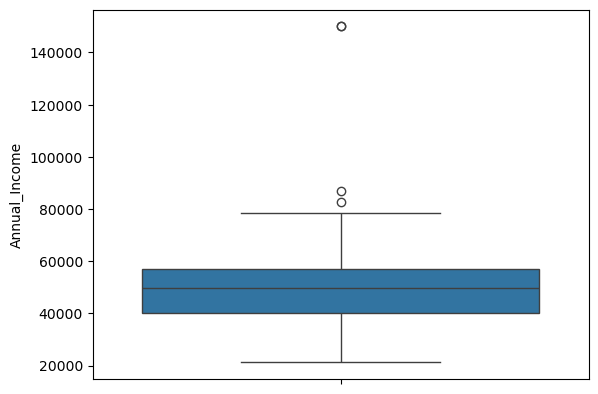

In [21]:
sns.boxplot(data['Annual_Income'])

In [22]:
def outlierDetection(column):
  #1. Sort the data in ascending order
  sorted(column)
  #2. Calc Q1 and Q3
  Q1,Q3 = np.percentile(column, [25,75])
  #3. Calc IQR
  IQR = Q3 - Q1
  #4. Calc valid range
  lowerRange = Q1 - (1.5 * IQR)
  upperRange = Q3 + (1.5 * IQR)
  return lowerRange, upperRange

In [24]:
lr,ur= outlierDetection(data['Annual_Income'])
lr,ur

(np.float64(14681.057183123034), np.float64(82140.33458244668))

In [25]:
data['Annual_Income'] > ur

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14     True
15    False
16    False
17    False
18    False
19    False
20    False
21    False
22    False
23    False
24    False
25     True
26    False
27    False
28    False
29    False
30    False
31    False
32    False
33    False
34    False
35    False
36    False
37     True
38    False
39    False
40    False
41    False
42    False
43    False
44    False
45    False
46    False
47     True
48    False
49    False
Name: Annual_Income, dtype: bool

In [26]:
processeddata = data[ (data['Annual_Income'] >= lr ) & (data['Annual_Income'] <= ur)]
processeddata.describe()

,Age,Annual_Income,Purchase_Frequency,Credit_Score,Encoded_Subscription_Status,Ed_lvl1
count,46.000000,46.000000,46.000000,46.000000,46.000000,46.000000
mean,39.565217,47283.260830,16.826087,655.716168,17.977391,1.826087
std,12.627399,12131.611437,15.467966,52.168736,0.404038,1.160543
min,19.000000,21218.431771,1.000000,548.742871,17.560000,0.000000
25%,31.250000,38555.701359,6.250000,619.497943,17.560000,1.000000
50%,39.000000,48232.012794,16.000000,654.899579,18.360000,2.000000
75%,46.750000,54310.310388,22.000000,678.418201,18.360000,3.000000
max,64.000000,78292.788518,100.000000,842.636575,18.360000,3.000000


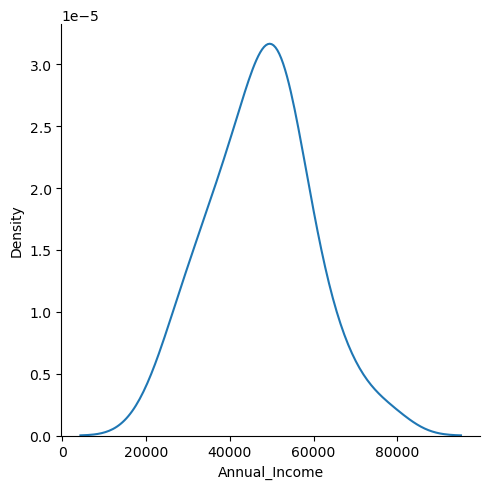

In [27]:
sns.displot(processeddata['Annual_Income'], kind='kde')

<Axes: ylabel='Annual_Income'>

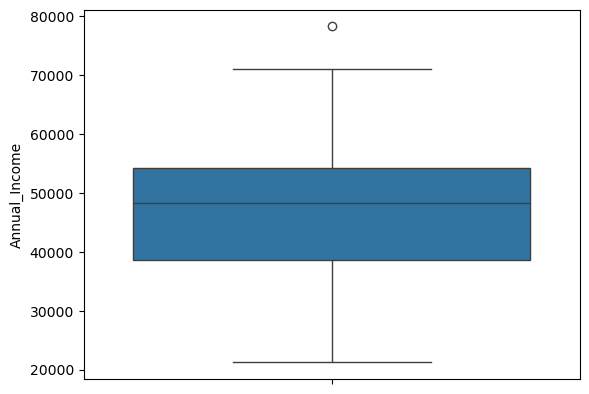

In [28]:
sns.boxplot(processeddata['Annual_Income'])

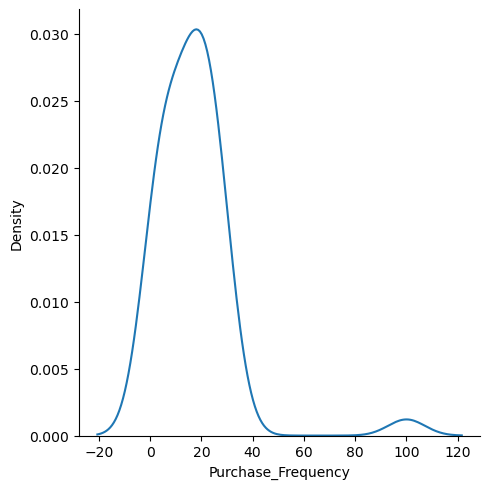

In [29]:
sns.displot(processeddata['Purchase_Frequency'], kind="kde")

In [30]:
#Detect and remove Outliers from Purchase_Frequency

lr,ur= outlierDetection(data['Purchase_Frequency'])
lr,ur

(np.float64(-18.0), np.float64(46.0))

In [31]:
processeddata = processeddata[ (processeddata['Purchase_Frequency'] >= lr ) & (processeddata['Purchase_Frequency'] <= ur)]
processeddata.describe()

,Age,Annual_Income,Purchase_Frequency,Credit_Score,Encoded_Subscription_Status,Ed_lvl1
count,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000
mean,39.733333,47526.018000,14.977778,655.602685,17.968889,1.844444
std,12.717919,12155.182735,9.163884,52.752490,0.404420,1.166883
min,19.000000,21218.431771,1.000000,548.742871,17.560000,0.000000
25%,31.000000,39469.203592,6.000000,617.419983,17.560000,1.000000
50%,39.000000,48883.311264,16.000000,654.899579,18.360000,2.000000
75%,47.000000,54441.804156,22.000000,678.544526,18.360000,3.000000
max,64.000000,78292.788518,29.000000,842.636575,18.360000,3.000000


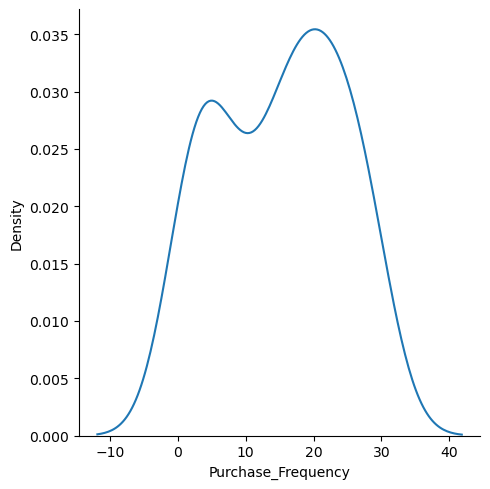

In [32]:
sns.displot(processeddata['Purchase_Frequency'], kind="kde")

In [33]:
from scipy import stats
processeddata['Z_score_Purchase_Frequency'] = stats.zscore(processeddata['Purchase_Frequency'])
processeddata.head()


,Customer_ID,Age,Gender,City,Annual_Income,Education_Level,Purchase_Frequency,Subscription_Status,Credit_Score,Product_Category,Encoded_Subscription_Status,Ed_lvl1,Z_score_Purchase_Frequency
0,CUST_1,56.0,Other,Chicago,42053.596943,Master's,3.0,Active,654.899579,Electronics,17.56,2,-1.321833
1,CUST_2,46.0,Other,New York,57699.011497,Master's,25.0,Inactive,654.899579,Sports,18.36,2,1.106024
2,CUST_3,32.0,Male,Chicago,51456.163240,Bachelor's,29.0,Active,667.889368,Sports,17.56,1,1.547452
3,CUST_4,60.0,Other,Miami,64529.674858,Bachelor's,18.0,Inactive,678.039226,Electronics,18.36,1,0.333524
4,CUST_5,25.0,Other,Los Angeles,39469.203592,Master's,14.0,Active,704.152562,Sports,17.56,2,-0.107905


In [34]:
processeddata[processeddata['Z_score_Purchase_Frequency'] > 3 ]

,Customer_ID,Age,Gender,City,Annual_Income,Education_Level,Purchase_Frequency,Subscription_Status,Credit_Score,Product_Category,Encoded_Subscription_Status,Ed_lvl1,Z_score_Purchase_Frequency


In [35]:

#No outliers detected in Purchase_Frequency using zscore
